In [3]:
import scipy.io
import os
import sys
import numpy as np
import h5py
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import random

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --- 1. Data Loading and Initial Reshaping ---

# (All function definitions from your original code are kept here)
name_format = "SBI_Bz_run23_new"
print("Note: use results33.mat which has 10000 datasets; B only has positive Z values, learning rate 0.0001, batch size 32.")
file_path = os.path.join('MATLAB_DATA', 'results33.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

# Define the list of files that should be processed as HDF5 files
h5_file_numbers = {3, 6, 7, 9}


# Function to load data from .h5 file
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw


# Function to load data from .mat file
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw


# Function to resample and smooth data
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new


# Function to process data
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)


# Main function to determine the type of file and load data accordingly
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)
print("Data loading and resampling completed.")

# Combine target variables into a single raw numpy array
target_data_raw = np.hstack((
    B_MAG_data[:, 2].reshape(-1, 1),
    EDC_MAG_data[:, 0].reshape(-1, 1),
    EDC_MAG_data[:, 1].reshape(-1, 1),
    EDC_MAG_data[:, 2].reshape(-1, 1)
))
input_data_raw = I_data

# --- 2. Train-Test Split (Applied BEFORE any normalization/scaling) ---
input_train_raw, input_test_raw, target_train_raw, target_test_raw = train_test_split(
    input_data_raw, target_data_raw, test_size=0.2, random_state=42
)
print(f"Data split into {len(input_train_raw)} training samples and {len(input_test_raw)} testing samples.")


# --- 3. Input Data Preprocessing (Z-Score Normalization) ---

# Calculate std dev for filtering *only* from the training set to find the feature window
stds_train = np.std(input_train_raw, axis=0)
start_index, end_index = 0, input_train_raw.shape[1] - 1
for i in range(input_train_raw.shape[1]):
    if stds_train[i] >= 0.01:
        start_index = i
        break
for i in range(input_train_raw.shape[1] - 1, -1, -1):
    if stds_train[i] >= 0.01:
        end_index = i
        break
print(f"Input data will be filtered from column {start_index} to {end_index} based on training set variance.")

# Apply the same fixed window to both train and test sets
I_train_filtered = input_train_raw[:, start_index:end_index + 1]
I_test_filtered = input_test_raw[:, start_index:end_index + 1]

# Calculate mean and std for normalization *only* from the filtered training set
means_train_filtered = np.mean(I_train_filtered, axis=0)
stds_train_filtered = np.std(I_train_filtered, axis=0)

# Apply the z-score transformation to both sets using the parameters from the training set
normalized_I_train = (I_train_filtered - means_train_filtered) / stds_train_filtered
normalized_I_test = (I_test_filtered - means_train_filtered) / stds_train_filtered

# This function is now used to interpolate the filtered data back to a fixed length of 1200
def interpolate_to_fixed_length(data, new_length=1200):
    resampled_data = []
    for row in data:
        x_original = np.linspace(0, 1, num=len(row))
        x_new = np.linspace(0, 1, num=new_length)
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_data.append(f(x_new))
    return np.array(resampled_data)

input_data_train_np = interpolate_to_fixed_length(normalized_I_train)
input_data_test_np = interpolate_to_fixed_length(normalized_I_test)

print("Input (z-score) preprocessing complete.")


# --- 4. Target Data Preprocessing (MinMax Scaling) ---

# Separate the raw target components for both train and test sets
B3_train, E1_train, E2_train, E3_train = target_train_raw[:,0:1], target_train_raw[:,1:2], target_train_raw[:,2:3], target_train_raw[:,3:4]
B3_test, E1_test, E2_test, E3_test = target_test_raw[:,0:1], target_test_raw[:,1:2], target_test_raw[:,2:3], target_test_raw[:,3:4]


# Initialize a separate scaler for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

# Fit and transform the TRAINING data components
B3_train_scaled = scaler_B3.fit_transform(B3_train)
E1_train_scaled = scaler_E1.fit_transform(E1_train)
E2_train_scaled = scaler_E2.fit_transform(E2_train)
E3_train_scaled = scaler_E3.fit_transform(E3_train)

# ONLY transform the TESTING data components using the scalers fit on the training data
B3_test_scaled = scaler_B3.transform(B3_test)
E1_test_scaled = scaler_E1.transform(E1_test)
E2_test_scaled = scaler_E2.transform(E2_test)
E3_test_scaled = scaler_E3.transform(E3_test)

# Recombine the scaled components into the final target data arrays
target_data_train_np = np.hstack((B3_train_scaled, E1_train_scaled, E2_train_scaled, E3_train_scaled))
target_data_test_np = np.hstack((B3_test_scaled, E1_test_scaled, E2_test_scaled, E3_test_scaled))

print("Target (MinMax) preprocessing complete.")

# --- 5. Convert Final Numpy Arrays to PyTorch Tensors ---

target_data_train_tensor = torch.tensor(target_data_train_np, dtype=torch.float32)
target_data_test_tensor = torch.tensor(target_data_test_np, dtype=torch.float32)
input_data_train_tensor = torch.tensor(input_data_train_np, dtype=torch.float32)
input_data_test_tensor = torch.tensor(input_data_test_np, dtype=torch.float32)


print("Data organized.", flush=True)

Note: use results33.mat which has 10000 datasets; B only has positive Z values, learning rate 0.0001, batch size 32.
Processing results33.mat as a .mat file...
Data loading and resampling completed.
Data split into 8000 training samples and 2000 testing samples.
Input data will be filtered from column 363 to 864 based on training set variance.
Input (z-score) preprocessing complete.
Target (MinMax) preprocessing complete.
Data organized.


In [4]:
# Define prior for SNPE
prior_min = torch.tensor([target_data_train_tensor.min().item()] * target_data_train_tensor.shape[1])
prior_max = torch.tensor([target_data_train_tensor.max().item()] * target_data_train_tensor.shape[1])
margin = 0.1 * (prior_max - prior_min)
prior = sbi_utils.BoxUniform(low=prior_min - margin, high=prior_max + margin)

In [5]:
# Train the SNPE model
print("Start training.", flush=True)
import time

Start training.


In [6]:
neural_net = posterior_nn(model='nsf', hidden_features=64, num_transforms=10)
inference = SNPE(prior=prior, density_estimator=neural_net)

In [7]:
# inference.append_simulations(target_data_train_tensor, input_data_train_tensor)
# density_estimator = inference.train(max_num_epochs=200, learning_rate=0.0001, training_batch_size=32)
# posterior = inference.build_posterior(density_estimator)

In [8]:
# Save the model
posterior_path = os.path.join("/home/botingl/machine learning copy", generate_filename("posterior", "pt"))
density_estimator_path = os.path.join("/home/botingl/machine learning copy", generate_filename("density_estimator", "pt"))

In [9]:
# torch.save(posterior, posterior_path)
# torch.save(density_estimator.state_dict(), density_estimator_path)

In [10]:
print("Model saved successfully.")

Model saved successfully.


In [11]:
# Load the saved model
posterior = torch.load(posterior_path)
print("Model loaded successfully.")

Model loaded successfully.


In [12]:
# Whole model evaluation (NMSE, rMAE, R²)
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

In [13]:
# Component-wise evaluation (MSE, MAE, R²)
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

In [15]:
# Evaluation metrics for the training data
print("Start to evaluate the training set.", flush=True)
size = len(input_data_train_np) if len(input_data_train_np) < 1000 else 1000
train_subset_indices = np.random.choice(len(input_data_train_np), size=size, replace=False)
train_input_data_subset = input_data_train_np[train_subset_indices]
train_target_data_subset = target_data_train_np[train_subset_indices]

Start to evaluate the training set.


In [16]:
# Measure the time taken for the entire prediction process
start_time = time.time()

In [17]:
# Generate predictions for the test set
predictions_train = []
for i in tqdm(range(len(train_input_data_subset)), desc="Processing samples", leave=True, file=sys.stdout):
    train_input = train_input_data_subset[i]  # This is the X and I for this test sample
    predicted_posterior = posterior.sample((1000,), x=train_input, show_progress_bars=False)  # Disable internal progress bars
    
    # Extract mean prediction for B and E
    predicted_mean = predicted_posterior.mean(dim=0)
    predictions_train.append(predicted_mean)
    
    sys.stdout.flush()  # Manually flush output

Processing samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/botingl/miniconda3/envs/portal_new/lib/python3.8/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at  ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2189.)
  outputs, _ = torch.triangular_solve(


Processing samples: 100%|██████████| 1000/1000 [08:11<00:00,  2.03it/s]


In [18]:
# Measure the end time
end_time = time.time()

In [19]:
time_taken = end_time - start_time

In [20]:
num_input = len(train_input_data_subset)

In [21]:
time_each = time_taken/num_input
print(f"Time taken for prediction on each training set: {time_each:.6f} seconds")

Time taken for prediction on each training set: 0.499564 seconds


In [22]:
# Convert predictions to numpy array
predictions_train = torch.stack(predictions_train).detach().numpy()

In [23]:
# Scale back the predicted values to original range
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

In [24]:
# Scale back the true values to original range
B_true_train = scaler_B3.inverse_transform(train_target_data_subset[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(train_target_data_subset[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(train_target_data_subset[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(train_target_data_subset[:, 3].reshape(-1, 1))
))

In [25]:
# Combine the scaled-back true and predicted values for evaluation
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

In [26]:
# Whole model evaluation
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.00871626288687975, rMAE: 0.02437322156385375, R²: 0.9886589514205949


In [27]:
# Component-wise evaluation
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

In [28]:
# Output the evaluation for each component
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 7.542706797284442e-07, MAE = 0.0004863979608558864, R² = 0.9999006845138529
E1: MSE = 544.9052880180776, MAE = 8.83883865235611, R² = 0.9740404389468322
E2: MSE = 11.4270443236676, MAE = 1.7172182377343614, R² = 0.9994619343602237
E3: MSE = 408.7658756494304, MAE = 7.698490492320125, R² = 0.981232747861471


In [29]:
# Save evaluation metrics to a text file
metrics_train_file = os.path.join("/home/botingl/machine learning copy", generate_filename("evaluation_metrics_train", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}\n")
    f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
    f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
    f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
    f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

In [30]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


In [31]:
# Evaluate the model on the testing set
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


In [38]:
# Generate predictions for the test set
predictions_test = []
for i in tqdm(range(len(input_data_test_np)), desc="Processing samples", leave=True, file=sys.stdout):
    test_input = input_data_test_np[i]  # This is the X and I for this test sample
    predicted_posterior = posterior.sample((1000,), x=test_input, show_progress_bars=False)  # Disable internal progress bars
    
    # Extract mean prediction for B and E
    predicted_mean = predicted_posterior.mean(dim=0)
    predictions_test.append(predicted_mean)
    
    sys.stdout.flush()  # Manually flush output

Processing samples: 100%|██████████| 2000/2000 [11:55<00:00,  2.80it/s] 


In [39]:
predictions_test = torch.stack(predictions_test).detach().numpy()

In [40]:
# Scale back the predicted values to original range for the test data
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In [41]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

In [44]:
# Scale back the true values to original range for the test data
B_true_test = scaler_B3.inverse_transform(target_data_test_np[:, 0].reshape(-1, 1))

In [46]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_data_test_np[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_test_np[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_test_np[:, 3].reshape(-1, 1))
))

In [47]:
# Combine the scaled-back true and predicted values for evaluation (test data)
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

In [48]:
# Whole model evaluation
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.011112911797516523, rMAE: 0.026980832254743334, R²: 0.9855904997114225


In [49]:
# Component-wise evaluation
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

In [50]:
# Output the evaluation for each component
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 9.116525986121434e-07, MAE = 0.000502053464439361, R² = 0.9998747707747375
E1: MSE = 650.0712712257199, MAE = 9.36687710266856, R² = 0.969895119451752
E2: MSE = 18.300765488640504, MAE = 1.963133339452907, R² = 0.9991111920525706
E3: MSE = 551.9118674979474, MAE = 8.879431047746504, R² = 0.9734809165666299


In [51]:
# Save evaluation metrics to a text file
metrics_train_file = os.path.join("/home/botingl/machine learning copy", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
    f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
    f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
    f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
    f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

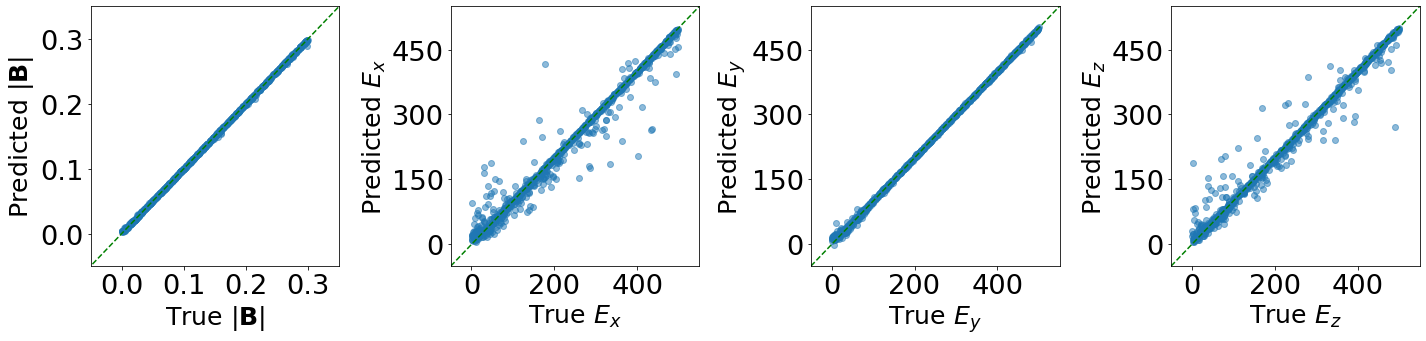

Training set evaluation done.


In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# Define a global font scaling factor
scale = 2.1 

# Base font sizes
base_label = 12
base_suptitle = 14
base_ticks = 13

plt.figure(figsize=(20, 5))

# --- B3 ---
ax1 = plt.subplot(1, 4, 1)
ax1.scatter(B_true_train, B_pred_train, alpha=0.5)
ax1.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
ax1.set_xlim(-0.05, 0.35)
ax1.set_ylim(-0.05, 0.35)
ax1.set_xlabel('True $|\\mathbf{B}|$', fontsize=base_label*scale)
ax1.set_ylabel('Predicted $|\\mathbf{B}|$', fontsize=base_label*scale)
ax1.tick_params(labelsize=base_ticks*scale)
# Reduce x ticks only for the first subplot
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# Reduce y ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# --- E1 ---
ax2 = plt.subplot(1, 4, 2)
ax2.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
ax2.plot([-50, 550], [-50, 550], 'g--')
ax2.set_xlim(-50, 550)
ax2.set_ylim(-50, 550)
ax2.set_xlabel('True $E_x$', fontsize=base_label*scale)
ax2.set_ylabel('Predicted $E_x$', fontsize=base_label*scale)
ax2.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax2.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax2.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# --- E2 ---
ax3 = plt.subplot(1, 4, 3)
ax3.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
ax3.plot([-50, 550], [-50, 550], 'g--')
ax3.set_xlim(-50, 550)
ax3.set_ylim(-50, 550)
ax3.set_xlabel('True $E_y$', fontsize=base_label*scale)
ax3.set_ylabel('Predicted $E_y$', fontsize=base_label*scale)
ax3.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax3.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax3.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax3.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# --- E3 ---
ax4 = plt.subplot(1, 4, 4)
ax4.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
ax4.plot([-50, 550], [-50, 550], 'g--')
ax4.set_xlim(-50, 550)
ax4.set_ylim(-50, 550)
ax4.set_xlabel('True $E_z$', fontsize=base_label*scale)
ax4.set_ylabel('Predicted $E_z$', fontsize=base_label*scale)
ax4.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax4.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax4.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax4.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax4.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# Figure title
# plt.suptitle('True vs. Predicted Components Using SBI (Training Data)', fontsize=base_suptitle*scale)

# Layout & save
plt.tight_layout(rect=[0, 0, 1, 0.97])
figure_train_file = os.path.join("/home/botingl/machine learning copy/Plots", 
                                 generate_filename("true_vs_predictions_train", "pdf"))
plt.savefig(figure_train_file, dpi=300, facecolor='white')
plt.show()

print("Training set evaluation done.", flush=True)


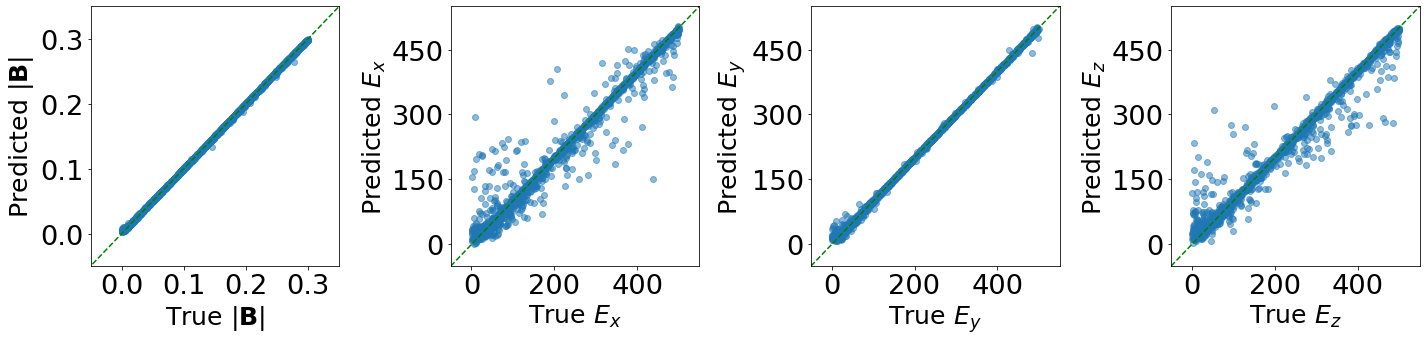

Testing set evaluation done.


In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# Define a global font scaling factor
scale = 2.1 

# Base font sizes
base_label = 12
base_suptitle = 14
base_ticks = 13

plt.figure(figsize=(20, 5))

# --- B3 ---
ax1 = plt.subplot(1, 4, 1)
ax1.scatter(B_true_test, B_pred_test, alpha=0.5)
ax1.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
ax1.set_xlim(-0.05, 0.35)
ax1.set_ylim(-0.05, 0.35)
ax1.set_xlabel('True $|\mathbf{B}|$', fontsize=base_label*scale)
ax1.set_ylabel('Predicted $|\mathbf{B}|$', fontsize=base_label*scale)
ax1.tick_params(labelsize=base_ticks*scale)
# Reduce x ticks only for the first subplot
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# Reduce y ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# --- E1 ---
ax2 = plt.subplot(1, 4, 2)
ax2.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
ax2.plot([-50, 550], [-50, 550], 'g--')
ax2.set_xlim(-50, 550)
ax2.set_ylim(-50, 550)
ax2.set_xlabel('True $E_x$', fontsize=base_label*scale)
ax2.set_ylabel('Predicted $E_x$', fontsize=base_label*scale)
ax2.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax2.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax2.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# --- E2 ---
ax3 = plt.subplot(1, 4, 3)
ax3.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
ax3.plot([-50, 550], [-50, 550], 'g--')
ax3.set_xlim(-50, 550)
ax3.set_ylim(-50, 550)
ax3.set_xlabel('True $E_y$', fontsize=base_label*scale)
ax3.set_ylabel('Predicted $E_y$', fontsize=base_label*scale)
ax3.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax3.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax3.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax3.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# --- E3 ---
ax4 = plt.subplot(1, 4, 4)
ax4.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
ax4.plot([-50, 550], [-50, 550], 'g--')
ax4.set_xlim(-50, 550)
ax4.set_ylim(-50, 550)
ax4.set_xlabel('True $E_z$', fontsize=base_label*scale)
ax4.set_ylabel('Predicted $E_z$', fontsize=base_label*scale)
ax4.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax4.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax4.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax4.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax4.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# Figure title
# plt.suptitle('True vs. Predicted Components Using SBI (Testing Data)', fontsize=base_suptitle*scale)

# Layout & save
plt.tight_layout(rect=[0, 0, 1, 0.97])
figure_test_file = os.path.join("/home/botingl/machine learning copy/Plots", 
                                generate_filename("true_vs_predictions_test", "pdf"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

print("Testing set evaluation done.", flush=True)


In [54]:
print("Testing set evaluation done.", flush=True)

Testing set evaluation done.


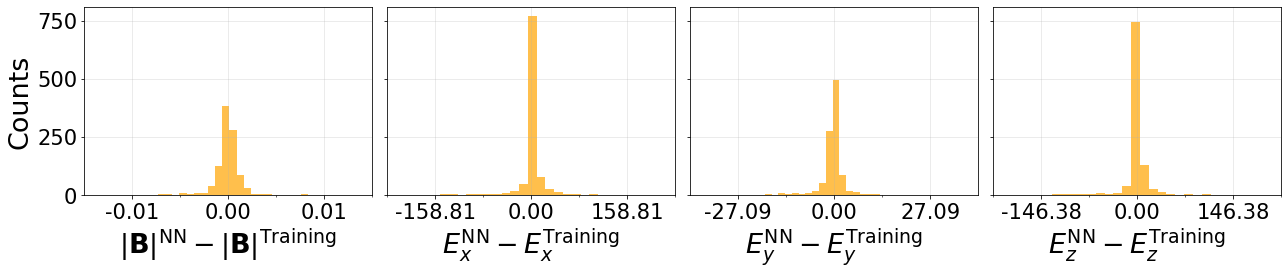

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

# Adjustable font sizes
scale = 1.5
label_fontsize = int(18 * scale)
tick_fontsize  = int(14 * scale)

# Errors (assumed already defined)
B3_error_train = B_true_train - B_pred_train
E1_error_train = E_true_train[:, 0] - E_pred_train[:, 0]
E2_error_train = E_true_train[:, 1] - E_pred_train[:, 1]
E3_error_train = E_true_train[:, 2] - E_pred_train[:, 2]

data_list = [
    (B3_error_train, r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Training}}$'),
    (E1_error_train, r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Training}}$'),
    (E2_error_train, r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Training}}$'),
    (E3_error_train, r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Training}}$')
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, (data, xlabel) in enumerate(data_list):
    ax = axs[i]
    ax.hist(data, bins=30, color='orange', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Counts', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='both', labelsize=tick_fontsize)

    # --- force symmetry around zero, subplot by subplot ---
    lim = np.max(np.abs([data.min(), data.max()]))
    ax.set_xlim(-lim, lim)

    # Make x ticks denser: about 6–8 major ticks
    step = (2 * lim) / 3.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # --- format x ticks with two decimals ---
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))


plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/SBI_training_histogram.pdf", dpi=300, facecolor='white')
plt.show()


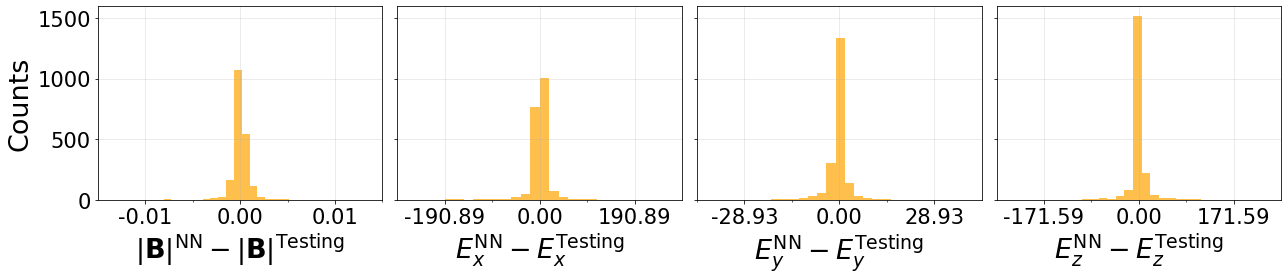

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

# Adjustable font sizes
scale = 1.5
label_fontsize = int(18 * scale)
tick_fontsize  = int(14 * scale)

# Errors (assumed already defined)
B3_error_test = B_true_test - B_pred_test
E1_error_test = E_true_test[:, 0] - E_pred_test[:, 0]
E2_error_test = E_true_test[:, 1] - E_pred_test[:, 1]
E3_error_test = E_true_test[:, 2] - E_pred_test[:, 2]

data_list = [
    (B3_error_test, r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Testing}}$'),
    (E1_error_test, r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Testing}}$'),
    (E2_error_test, r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Testing}}$'),
    (E3_error_test, r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Testing}}$')
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, (data, xlabel) in enumerate(data_list):
    ax = axs[i]
    ax.hist(data, bins=30, color='orange', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Counts', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='both', labelsize=tick_fontsize)

    # --- force symmetry around zero, subplot by subplot ---
    lim = np.max(np.abs([data.min(), data.max()]))
    ax.set_xlim(-lim, lim)

    # Make x ticks denser: about 6–8 major ticks
    step = (2 * lim) / 3.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # --- format x ticks with two decimals ---
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))


plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/SBI_testing_histogram.pdf", dpi=300, facecolor='white')
plt.show()
